In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from collections import Counter
from rdkit.Chem import AllChem, DataStructs
from rdkit import Chem
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [ ]:
def smiles_to_morgan_fp(smiles: str, n_bits: int = 1024, radius: int = 2) -> np.ndarray:
    """
    Converts a SMILES string to a Morgan fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles)    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

def show_random_molecules(smiles_list, N=5):
    """
    Given a list of smiles, returns N visualizations of molecules
    """
    # Randomly select N SMILES
    sampled_smiles = random.sample(smiles_list, min(N, len(smiles_list)))
    
    # Convert to RDKit Mol objects
    mols = [Chem.MolFromSmiles(smi) for smi in sampled_smiles]
    
    # Display molecules in a grid
    img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=sampled_smiles)
    img.show()

**REAL NEGATIVES**

In [35]:
df = pd.read_csv("/home/acomajuncosa/Downloads/activities_CHEMBL1794345.tsv", sep='\t', low_memory=False)
df = df[~df['Smiles'].isna()]
print("No pvalues: " + str([i for i in df['pChEMBL Value'].tolist() if not np.isnan(i)]))
print("All are nM: " + str(set([i for i in df['Standard Units']])))

# Generate pChEMBLs
df['pChEMBL_calculated'] = [-np.log10(i * 1e-09) for i in df['Standard Value']]

# Get actives and inactives
actives = df[df['pChEMBL_calculated'] >= 7]['Smiles'].tolist()
inactives = df[df['pChEMBL_calculated'] < 7]['Smiles'].tolist()
print("Actives: " + str(len(actives)))
print("Inactives: " + str(len(inactives)))

# Fix random seed
np.random.seed(42)

# Choose N actives and 1 * N inactives
N = 7000
selected_actives = np.random.choice(actives, N, replace=False).tolist()
selected_inactives = np.random.choice(inactives, 1 * N, replace=False).tolist()
print("Actives: " + str(len(selected_actives)))
print("Inactives: " + str(len(selected_inactives)))

# Get ECFPs
print("Calculating ECFPs...")
selected_actives = [smiles_to_morgan_fp(i) for i in selected_actives]
selected_inactives = [smiles_to_morgan_fp(i) for i in selected_inactives]

# Create matrices
X = np.array(selected_actives + selected_inactives)
Y = np.array([1]*len(selected_actives) + [0]*len(selected_inactives))
print("Matrix shapes:")
print(X.shape, Y.shape)

No pvalues: []
All are nM: {'nM'}
Actives: 7364
Inactives: 162948
Actives: 7000
Inactives: 7000
Calculating ECFPs...
Matrix shapes:
(14000, 1024) (14000,)


In [5]:
ind_act = np.where(Y == 1)[0]
ind_inact = np.where(Y == 0)[0]

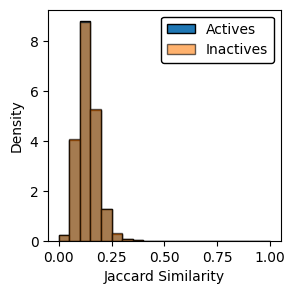

In [34]:
### DISTANCES ###

np.random.seed(42)
X_act_sample = X[ind_act][np.random.choice(len(ind_act), 1500, replace=False)].astype(bool)
X_inact_sample = X[ind_inact][np.random.choice(len(ind_inact), 1500, replace=False)].astype(bool)

dist_act = pairwise_distances(X_act_sample, metric='jaccard')[np.triu_indices(len(X_act_sample), k=1)]
dist_inact = pairwise_distances(X_act_sample, X_inact_sample, metric='jaccard').ravel()

dist_act = dist_act[np.random.choice(len(dist_act), 25000, replace=False)]
dist_inact = dist_inact[np.random.choice(len(dist_inact), 25000, replace=False)]

sim_act = 1 - dist_act
sim_inact = 1 - dist_inact

bins = [i for i in np.arange(0, 1.01, 0.05)]
plt.figure(figsize=(3, 3))
plt.xlabel("Jaccard Similarity")
plt.ylabel("Density")
plt.hist(sim_act, edgecolor='k', bins=bins, label='Actives', density=True)
plt.hist(sim_inact, edgecolor='k', bins=bins, label='Inactives', alpha=0.6, density=True)
plt.legend(loc='upper right', edgecolor='k', framealpha=1)
plt.show()

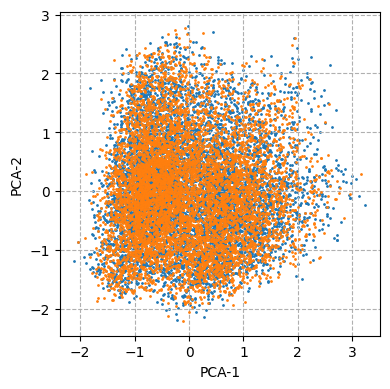

In [ ]:


# Apply PCA for dimensionality reduction to 2D
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(X)

# Plot the result
plt.figure(figsize=(4, 4))
plt.scatter(embedding[ind_inact][:, 0], embedding[ind_inact][:, 1], s=1, alpha=1, zorder=1)
plt.scatter(embedding[ind_act][:, 0], embedding[ind_act][:, 1], s=1, alpha=1, zorder=2)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()